<a href="https://colab.research.google.com/github/sugunasathiskumar/NLP/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [39]:
!pip install PyPDF2 python-docx

import os
import re
import string
import shutil

import pandas as pd
import numpy as np

from google.colab import files

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from PyPDF2 import PdfReader
from docx import Document

import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [40]:
uploaded = files.upload()

Saving news_dataset_200_articles.pdf to news_dataset_200_articles (1).pdf


In [41]:
filename = list(uploaded.keys())[0]

if filename.endswith(".txt"):

    with open(filename,"r",encoding="utf-8") as file:
        text = file.read()

elif filename.endswith(".pdf"):

    reader = PdfReader(filename)

    text = ""

    for page in reader.pages:
        text += page.extract_text()

elif filename.endswith(".docx"):

    doc = Document(filename)

    text = ""

    for para in doc.paragraphs:
        text += para.text + "\n"

print(text[:2000])

Article 1 (Cricket)
India defeated Australia in a thrilling cricket match. A star batter scored a century while the bowlers
defended the target successfully. Article number 1. Local officials and citizens responded according
to the situation. Experts said further updates are expected soon.
Article 2 (Crime)
Police arrested suspects after investigating a robbery case using CCTV footage and forensic
evidence. Article number 2. Local officials and citizens responded according to the situation.
Experts said further updates are expected soon.
Article 3 (Business)
The stock market gained after companies announced strong quarterly earnings and investor
confidence improved. Article number 3. Local officials and citizens responded according to the
situation. Experts said further updates are expected soon.
Article 4 (Politics)
The government announced a new policy focusing on education, infrastructure, and economic
development. Article number 4. Local officials and citizens responded according t

In [61]:
articles = re.split(r'\n\s*\n', text)

articles = [i.strip() for i in articles if len(i.strip())>50]

print("Total Articles :",len(articles))

Total Articles : 1


In [43]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [44]:
def preprocess(text):

    text = text.lower()

    text = re.sub(r'http\S+',' ',text)

    text = re.sub(r'[^a-zA-Z ]',' ',text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [45]:
import nltk
nltk.download('punkt_tab')

clean_articles = []

for article in articles:

    clean_articles.append(preprocess(article))

print(clean_articles[0])

article cricket india defeated australia thrilling cricket match star batter scored century bowler defended target successfully article number local official citizen responded according situation expert said update expected soon article crime police arrested suspect investigating robbery case using cctv footage forensic evidence article number local official citizen responded according situation expert said update expected soon article business stock market gained company announced strong quarterly earnings investor confidence improved article number local official citizen responded according situation expert said update expected soon article politics government announced new policy focusing education infrastructure economic development article number local official citizen responded according situation expert said update expected soon article technology researcher unveiled innovative ai system improves automation cybersecurity language processing article number local official citizen 

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [46]:
df = pd.read_csv("news_dataset.csv")

df.head()

,text,category
0,India won the cricket match,Cricket
1,Police arrested three robbers,Crime
2,Stock market reached new highs,Business
3,Actor announced new movie,Entertainment
4,Heavy rain caused floods,Weather


In [47]:
df["clean_text"] = df["text"].apply(preprocess)

In [48]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_text"])

y = df["category"]

In [49]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
model = MultinomialNB()

model.fit(X_train,y_train)

MultinomialNB()

In [51]:
pred = model.predict(X_test)

print("Accuracy")

print(accuracy_score(y_test,pred))

print()

print(classification_report(y_test,pred))

Accuracy
0.0

              precision    recall  f1-score   support

     Cricket       0.00      0.00      0.00       0.0
       Crime       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [52]:
article_vectors = vectorizer.transform(clean_articles)

predicted_categories = model.predict(article_vectors)

In [53]:
for i,cat in enumerate(predicted_categories):

    print("="*50)

    print("Article",i+1)

    print("Category :",cat)

    print()

Article 1
Category : Entertainment



In [54]:
sia = SentimentIntensityAnalyzer()

sentiments = []

for article in articles:

    score = sia.polarity_scores(article)

    compound = score["compound"]

    if compound >= 0.05:

        sentiment = "Happy"

    elif compound <= -0.05:

        sentiment = "Sad"

    else:

        sentiment = "Neutral"

    sentiments.append(sentiment)

In [55]:
for i,s in enumerate(sentiments):

    print("Article",i+1,"->",s)

Article 1 -> Happy


In [56]:
output_folder = "Categorized_News"

os.makedirs(output_folder,exist_ok=True)

for article,category in zip(articles,predicted_categories):

    folder = os.path.join(output_folder,category)

    os.makedirs(folder,exist_ok=True)

    count = len(os.listdir(folder))+1

    with open(os.path.join(folder,f"article_{count}.txt"),"w",encoding="utf-8") as file:

        file.write(article)

In [57]:
results = pd.DataFrame({

    "Article":articles,

    "Category":predicted_categories,

    "Sentiment":sentiments

})

results.to_csv("News_Result.csv",index=False)

results.head()

,Article,Category,Sentiment
0,Article 1 (Cricket)\nIndia defeated Australia ...,Entertainment,Happy


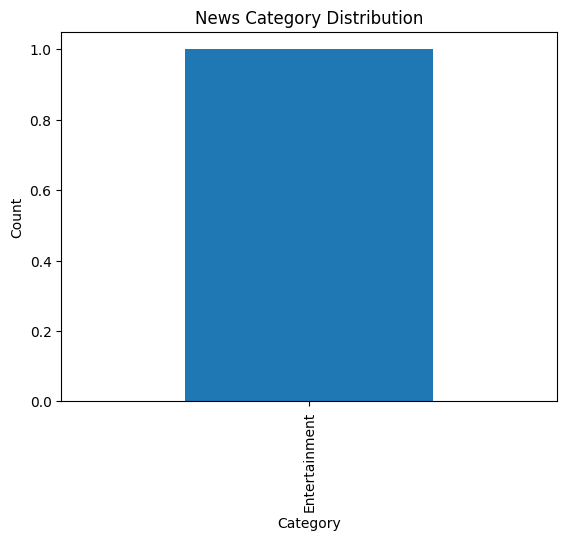

In [62]:
results["Category"].value_counts().plot(kind="bar")

plt.title("News Category Distribution")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

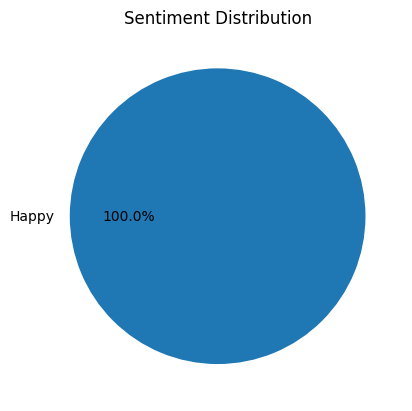

In [59]:
results["Sentiment"].value_counts().plot(

kind="pie",

autopct="%1.1f%%"

)

plt.ylabel("")

plt.title("Sentiment Distribution")

plt.show()

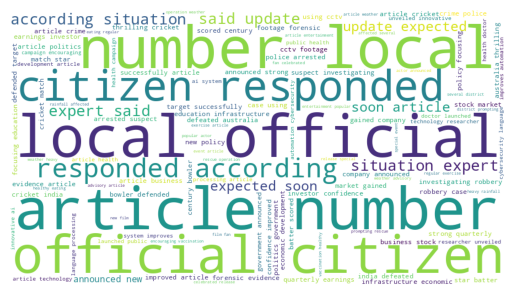

In [60]:
text = " ".join(clean_articles)

wc = WordCloud(

width=900,

height=500,

background_color="white"

).generate(text)

plt.imshow(wc)

plt.axis("off")

plt.show()